**About this notebook** 
- In 1.0-gna-data-import-exploration_v2, data was merged from various sources into one long format with a single row for each country and year.
- In v2 of this notebook. All imputation steps have been commented out since this code will be transferred to a later script such that these changes can me made only to training data. MMR dose count has also been deleted in favor of using the kindergarten coverage metric.
- This notebook was run on data created by the 1.0-gna-data-import-exploration_v2 script
- The data frames produced by this notebook will be run on 0.3-gna-preprocessing_and_training_v3

# 1. Imports

In [1]:
import numpy as np 
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

!pip install missingno
import missingno as msno

from sklearn.impute import SimpleImputer

# 2. Load data

In [2]:
!cd "/Users/grace/Documents/GitHubRepos/capstone2_immunization/"
data = pd.read_csv("/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/imm_df_cleaned.csv")

In [3]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 41 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   county_name                                    1016 non-null   object 
 1   % Low Birthweight                              470 non-null    float64
 2   # Primary Care Physicians                      934 non-null    float64
 3   Primary Care Physicians Rate                   934 non-null    float64
 4   % Vaccinated Flu                               1008 non-null   float64
 5   % Children in Poverty                          1016 non-null   float64
 6   Infant Mortality Rate                          304 non-null    float64
 7   # Uninsured Children                           1016 non-null   int64  
 8   % Uninsured Children                           1016 non-null   float64
 9   # Food Insecure                                1016 

In [4]:
# examine missing data per variable
missing_df = pd.DataFrame({'# Missing':data.isnull().sum(),'% Missing': round(data.isnull().sum()/len(data),2)})
missing_df.sort_values(by = '% Missing', ascending = False)

,# Missing,% Missing
Infant Mortality Rate,712,0.70
% Low Birthweight,546,0.54
% Broadband Access,508,0.50
% Less Than 18 Years of Age,508,0.50
Segregation index_b,345,0.34
live_births,278,0.27
% Female,254,0.25
% Rural,254,0.25
Primary Care Physicians Rate,82,0.08
# Primary Care Physicians,82,0.08


In [5]:
data['year'].unique()

array([2020, 2021, 2022, 2023])

# 3.  Exploratory Data Analysis

## Clean and examine numerical variables

In [6]:
numerical_cols = data.select_dtypes(['int','float']).columns
print(len(numerical_cols))
numerical_cols

37


Index(['% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'mmr_doses_0_24_months', 'mmr_doses_2_8_years', 'mmr_doses_9_17_years',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout',
       'other_pc_provider_ratio_numerator',
       'other_pc_provider_ratio_denominator'

In [7]:
numerical_cols_subset1 = ['% Low Birthweight',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '% Uninsured Children',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population',  'year', '% Broadband Access', '% Less Than 18 Years of Age', 'mmr_doses_0_24_months']
print(len(numerical_cols_subset1)) 

16


In [8]:
numerical_cols_subset2 = ['% Female', '% Rural','Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout', 'live_births',
       'other_pc_provider_ratio_numerator', 'mmr_doses_2_8_years',
       'mmr_doses_9_17_years','kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov']
print(len(numerical_cols_subset2))

17


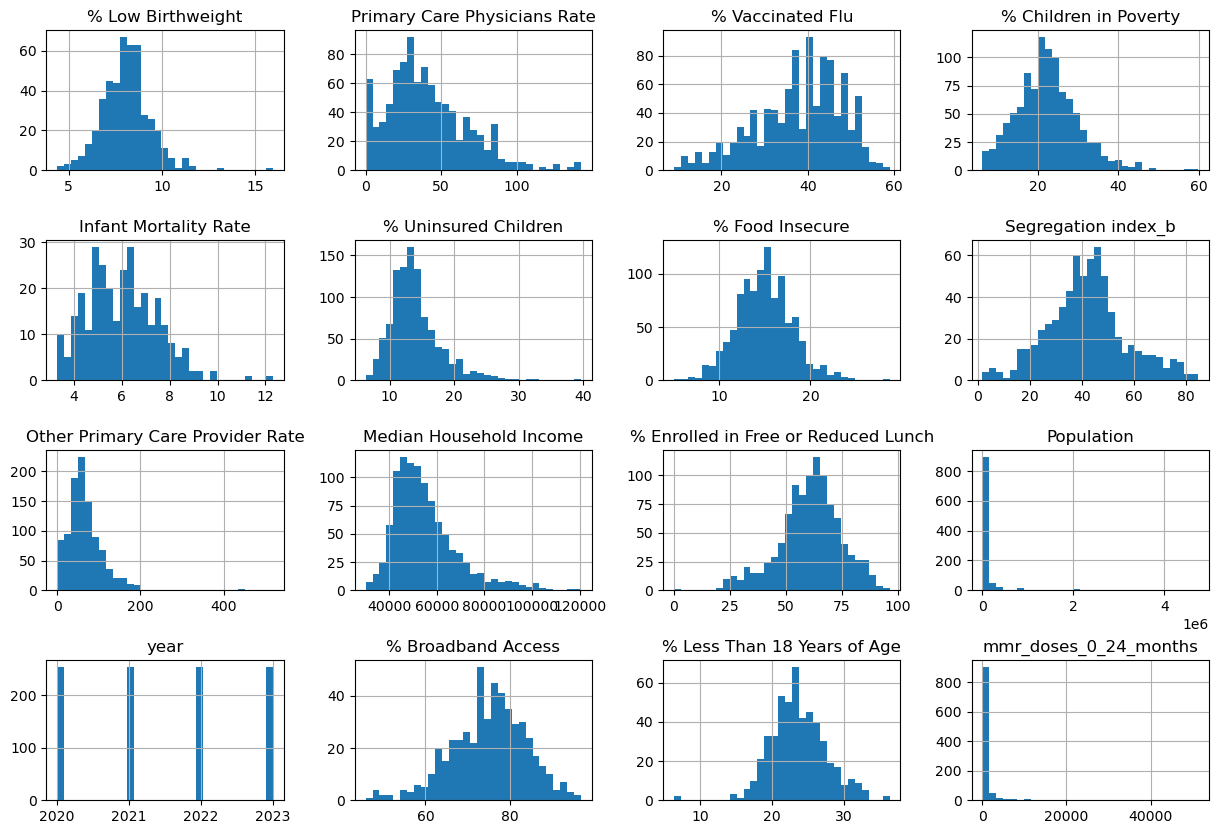

In [9]:
data[numerical_cols_subset1].hist(figsize=(15,10), bins = 31 )
plt.subplots_adjust(hspace=0.5)

There is a small minority of counties with huge populations. Make sure all the numeric variables are rates or per capita measures so that we don't see trends based on the unevent population county sizes. The main variable to be adjusted is the # of pediatric mmr dose varibles. 
Estimate MMR coverage based on the # of doses and the population of each county.

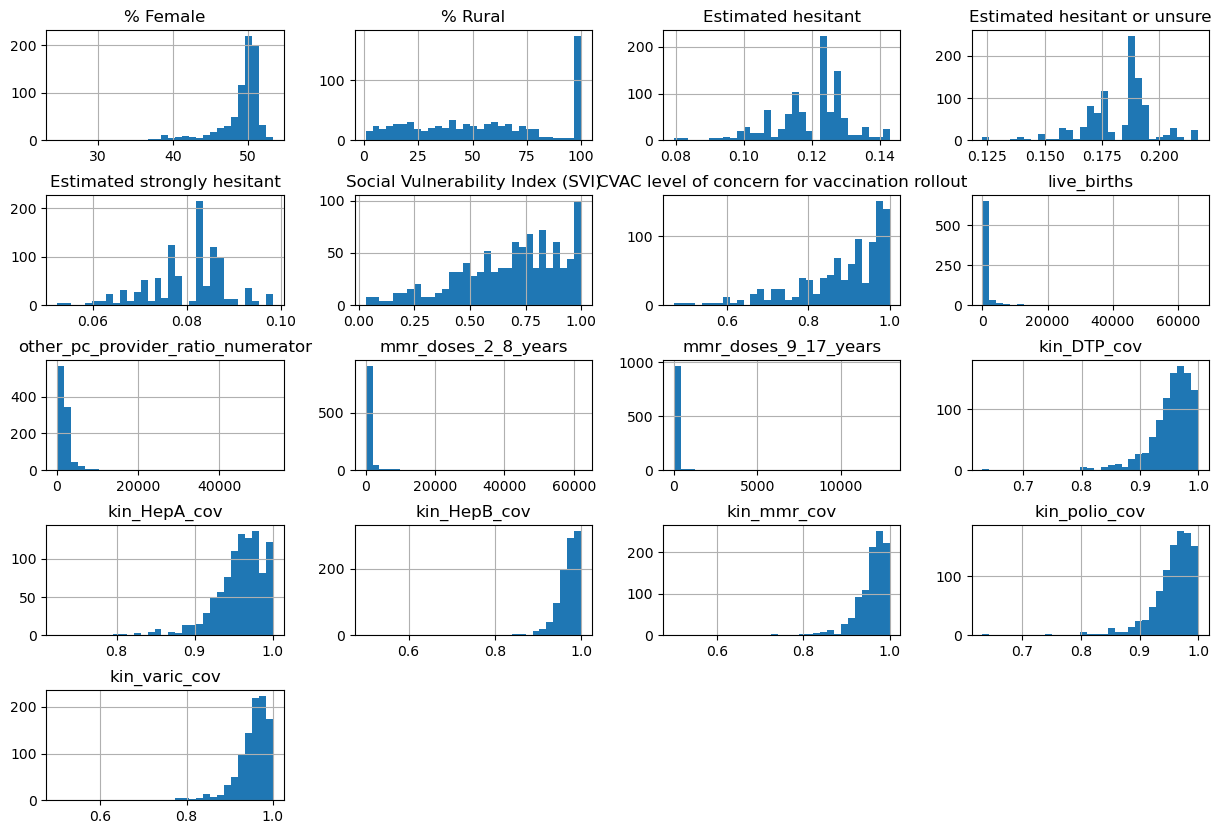

In [10]:
data[numerical_cols_subset2].hist(figsize=(15,10), bins = 31 )
plt.subplots_adjust(hspace=0.5)

Most variables are skewed left (SVI, CVAC levels) or right (immunization coverage levels among kindergarteners).

### County Population Size

In [11]:
# create a categorical variable for county population
p33 = np.percentile(data['Population'], 33.33)
p67 = np.percentile(data['Population'], 66.67)
print(f"33rd percentile: {p33:.0f} \n67th percentile: {p67:.0f}")
data['pop_tertiles'] = data['Population'].apply(lambda x: 'small' if x <p33 else ('medium' if p33<= x <p67 else 'large'))
data['pop_tertiles'].value_counts(dropna = False)

33rd percentile: 9438 
67th percentile: 36548


pop_tertiles
large     339
small     339
medium    338
Name: count, dtype: int64

In [12]:
# check to make sure categories were coded correctly
data['Population'].groupby(by = data['pop_tertiles']).agg('mean')

pop_tertiles
large     320180.823009
medium     19449.360947
small       4339.949853
Name: Population, dtype: float64

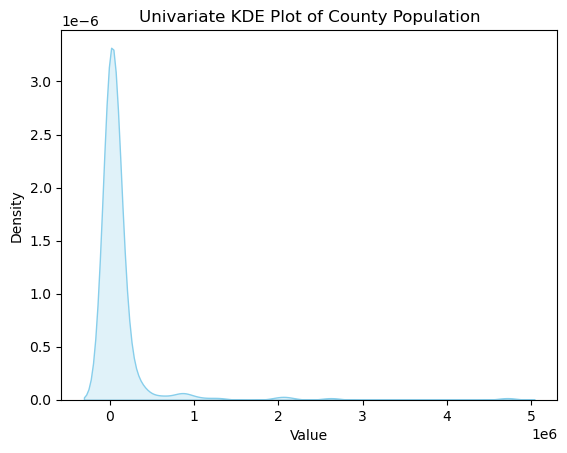

In [13]:
# Examine distribution of Population with kdensity plot
sns.kdeplot(x=data['Population'], fill=True, color='skyblue')
plt.title('Univariate KDE Plot of County Population')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [14]:
data['Population'].describe()

count    1.016000e+03
mean     1.147504e+05
std      4.093774e+05
min      5.700000e+01
25%      6.647000e+03
50%      1.864400e+04
75%      5.261150e+04
max      4.738253e+06
Name: Population, dtype: float64

### % Rural

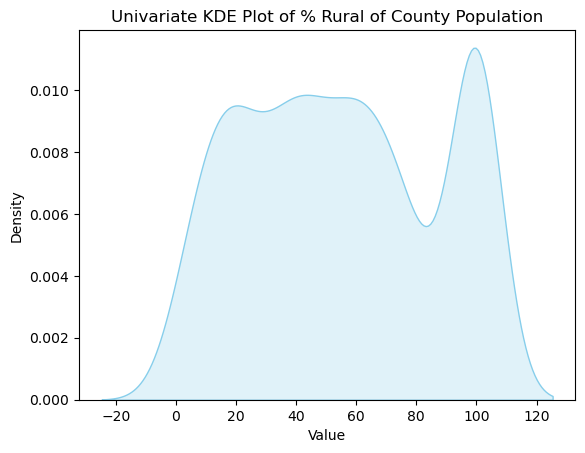

In [15]:
# Examine distribution of % Rural with kdensity plot
sns.kdeplot(x=data['% Rural'], fill=True, color='skyblue')
plt.title('Univariate KDE Plot of % Rural of County Population')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [16]:
# ensure there are no negative values
data['% Rural'].describe()

count    762.000000
mean      55.520241
std       31.861401
min        0.688304
25%       27.260558
50%       53.635841
75%       81.316514
max      100.000000
Name: % Rural, dtype: float64

In [17]:
# check to see how county % Rural values varied by year
data['% Rural'].groupby(by = data['year']).agg('mean')

year
2020    55.520241
2021    55.520241
2022          NaN
2023    55.520241
Name: % Rural, dtype: float64

#### impute % Rural - commented out

In [18]:
# Looks like the % Rural variable doesn't change at all year to year, but is missing for the 2022 counties
# impute the 2022 values based on other years
#year2022mask = data['year'] == 2022
#year2023mask = data['year'] == 2023
#print(type(year2022mask))
# data.loc[year2022mask, '% Rural'] = data.loc[year2023mask, '% Rural'] didn't work
#data['% Rural'].groupby(by = data['year']).agg('mean')

In [19]:
# create an index to copy 2023 '% Rural' values to 2022 '% Rural' values
# create dictionary that maps 2023 to 2022 indices
#indx_mapping = dict(zip(data[year2023mask].index, data[year2022mask].index))
# Use the mapping to copy values
#for idx_2023, idx_2022 in indx_mapping.items():
#    data.loc[idx_2022, '% Rural'] = data.loc[idx_2023, '% Rural']

In [20]:
#print(data['% Rural'].groupby(by = data['year']).agg('mean'))
#pd.crosstab(data['% Rural'].isna().sum(), data['year'], dropna = False)

In [21]:
# create a categorical variable for % rural county population
#p25, p50, p75 = np.percentile(data['% Rural'], [25, 50, 75])
#print(f"25th percentile: {p25:.0f} \n50th percentile: {p50:.0f}\n75th percentile: {p75:.0f}")

In [22]:
#data['rural_pop_quartiles'] = data['% Rural'].apply(lambda x: 'very urban' if x <p25 else
#                                                    ('urban' if p25<= x <p50 else
#                                                    ('rural' if p50 <= x <p75 else
#                                                    'very rural' )))
#print(data['rural_pop_quartiles'].value_counts(dropna = False))

In [23]:
# check categorical variable for % rural population
#print(data['% Rural'].groupby(by = data['rural_pop_quartiles']).agg('mean'))

Note that there is a large variation in the % of a county population that is rural. Looks a bit bimodal and a bit uniform from the kdensity plot above.
The quartiles for % Rural can be categorized as very urban (15% rural) all the way to very rural (98% rural).

### % Less Than 18 Years of Age - commented out

In [24]:
# examine how the missing data for this variable varies by year & categorical rural pop variable 
#print(data['% Less Than 18 Years of Age'].groupby(by = data['rural_pop_quartiles']).agg('mean'))
print(data['% Less Than 18 Years of Age'].groupby(by = data['year']).agg('mean'))


year
2020          NaN
2021    23.746129
2022    23.634888
2023          NaN
Name: % Less Than 18 Years of Age, dtype: float64


Half of the values for this variable appear to be missing for 2020 and 2023. There seem to be a slightly greater % of youth living in very urban counties relative to very rural counties. But there isn't much difference in the % of youth in rural vs. urban counties. The percentages in 2021 and 2022 aren't very different.

In [25]:
youth_vs_year = data[['% Less Than 18 Years of Age','year']]
(youth_vs_year
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)
# the weak correlation between the two columns suggests that we can use the existing % <18 yrs column to extrapolate for other years

,% Less Than 18 Years of Age,year
% Less Than 18 Years of Age,1.000000,-0.014514
year,-0.014514,1.000000


#### Impute % Less than 18 years of Age

Impute the missing % Less than 18 years of Age values by taking the average of 2021 and 2022 values, and using those for the 2020 and 2023 values. Use the missing indicator method (MIM) to also create a dummary variable indicating which % Youth population values were originally missing with the (SimpleImputer)[https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html].

In [26]:
# create masks for remaining years
#year2020mask = data['year'] == 2020
#year2021mask = data['year'] == 2021

In [27]:
# impute values for the missing '% Less than 18 Years of Age' column
#imputer = SimpleImputer(strategy = 'median', add_indicator = True)
#x = imputer.fit_transform(data[['% Less Than 18 Years of Age']])
#print(type(x))
#imputed_youth_df = pd.DataFrame(x, columns = ['%_pop_youth_imputed', '%_pop_youth_imputed_yes_no'])

In [28]:
# add imputed youth variables back to the original data frame
#print(f"Original data frame shape: {data.shape}")
#print(f"Imputed %youth data frame shape: {imputed_youth_df.shape}")
#data_test = pd.concat([data,imputed_youth_df], axis = 1)
#print(f"Combined data frame shape: {data_test.shape}")

In [29]:
#age_cols = ['% Less Than 18 Years of Age', '%_pop_youth_imputed', '%_pop_youth_imputed_yes_no']

In [30]:
#print(data_test[age_cols].groupby(by = data_test['year']).agg('mean'))

In [31]:
# check
#print(pd.crosstab(data_test['% Less Than 18 Years of Age'].isna().sum(), data_test['year'], margins = True, dropna = False))
#pd.crosstab(data_test['%_pop_youth_imputed'].isna().sum(), data_test['year'], margins = True, dropna = False)

In [32]:
# save changes with imputed data back to the original data frame
#data = data_test

Confirmed that data for the % pop <18 years old was imputed for 2020 and 2023. We have now two new columns for each county.
There is no missing data for the %_pop_youth_imputed'

## % Vaccinated Flu

In [33]:
print(data['% Vaccinated Flu'].groupby(by = data['year']).agg('mean'))


year
2020    36.388889
2021    37.845238
2022    37.861111
2023    39.563492
Name: % Vaccinated Flu, dtype: float64


### Infant mortality rate


In [34]:
pd.crosstab(data['Infant Mortality Rate'].isna().sum(), data['year'], margins = True, dropna = False)

year,2020,2021,2022,2023,All
row_0,,,,,
712,254,254,254,254,1016
All,254,254,254,254,1016


There are 712 values missing for each year? 

In [35]:
# pd.crosstab(data['Infant Mortality Rate'].isna().sum(), data['rural_pop_quartiles'], margins = True, dropna = False)

In [36]:
# examine the patterns of missing data for 'Infant Mortality Rate' before imputation
imr_missing_correlations = data[['Infant Mortality Rate','year','% Rural','Population']]
(imr_missing_correlations
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,Infant Mortality Rate,year,% Rural,Population
Infant Mortality Rate,1.000000,-0.076496,0.376255,-0.140222
year,-0.076496,1.000000,-0.000000,0.003059
% Rural,0.376255,-0.000000,1.000000,-0.358455
Population,-0.140222,0.003059,-0.358455,1.000000


#### Impute 'Infant Mortality Rate' - imputed out

In [37]:
# impute values for the missing column
#x = imputer.fit_transform(data[['Infant Mortality Rate']])
#print(type(x))
#imputed_imr_df = pd.DataFrame(x, columns = ['imr_imputed', 'imr_imputed_yes_no'])

In [38]:
# add imputed variables back to the original data frame
#print(f"Original data frame shape: {data.shape}")
#print(f"Imputed %imputed_imr_df data frame shape: {imputed_imr_df.shape}")
#data_test = pd.concat([data,imputed_imr_df], axis = 1)
#print(f"Combined data frame shape: {data_test.shape}")

In [39]:
#imr_cols = ['Infant Mortality Rate', 'imr_imputed', 'imr_imputed_yes_no']

In [40]:
#print(data_test[imr_cols].groupby(by = data_test['year']).agg('mean'))

In [41]:
# save changes over original
#data = data_test

### Live_births

In [42]:
pd.crosstab(data['live_births'].isna().sum(),data['year'], margins = True, dropna= False)

year,2020,2021,2022,2023,All
row_0,,,,,
278,254,254,254,254,1016
All,254,254,254,254,1016


#### Impute 'live_births' - commented out

In [43]:
# impute values for the missing column
#x = imputer.fit_transform(data[['live_births']])
#imputed_live_births_df = pd.DataFrame(x, columns = ['live_births_imputed', 'live_births_imputed_yes_no'])

In [44]:
#imputed_live_births_df.head()

In [45]:
# add imputed variables back to the original data frame
#print(f"Original data frame shape: {data.shape}")
#print(f"Imputed %live birth data frame shape: {imputed_live_births_df.shape}")
#data_test = pd.concat([data,imputed_live_births_df], axis = 1)
#print(f"Combined data frame shape: {data_test.shape}")

In [46]:
#lb_cols = ['live_births','live_births_imputed', 'live_births_imputed_yes_no']

In [47]:
#print(data_test[lb_cols].groupby(by = data_test['year']).agg('mean'))

In [48]:
# save modified over original
#data = data_test

Now that I have imputed the # of live births and the infant mortality rate in each county and year, I can use this to estimate the number of children that are 0-24 months old, which I will need to calulate MMR vaccine coverage for that age group. 

Infant mortality rate is the # of infant deaths between 0-12 months per 1000 live births.

In [49]:
# calculate the # of children under 24 months in each county based on the number of live births and the IMR
#data['pop_0_24mos'] = data['live_births_imputed']-((data['imr_imputed']/1000)* data['live_births_imputed'])

Technically, pop_0_24mos is the # of infants who survived the first year of life. However, since the IMR during 12-23 months is generally lower than in the first 12 months of old. This is a good approximation. It's also appropriate given the # of doses are for all children 0-24 months of old, and 12 months falls exactly in the middle of that age range.

In [50]:
#print(data[['live_births_imputed','pop_0_24mos','imr_imputed']].groupby(by = data['year']).agg('mean'))

In [51]:
data.filter(like = 'mmr').columns

Index(['mmr_doses_0_24_months', 'mmr_doses_2_8_years', 'mmr_doses_9_17_years',
       'kin_mmr_cov'],
      dtype='object')

In [52]:
data.filter(like = '18').columns

Index(['% Less Than 18 Years of Age'], dtype='object')

### Kindergarten coverage levels

In [53]:
data.filter(like = 'kin_').columns

Index(['kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov', 'kin_mmr_cov',
       'kin_polio_cov', 'kin_varic_cov'],
      dtype='object')

In [54]:
# examine missing data for 'kin_mmr_cov'
print("Missing data for mmr coverage", data['kin_mmr_cov'].isnull().sum())
print(pd.crosstab(data['year'],data['kin_mmr_cov'].isnull()))

Missing data for mmr coverage 20
kin_mmr_cov  False  True 
year                     
2020           250      4
2021           249      5
2022           248      6
2023           249      5


In [55]:
cols_to_show = ['county_name', 'year', '% Rural','kin_mmr_cov']
missing_mmr_coverage_df = data.loc[data['kin_mmr_cov'].isnull(),cols_to_show].sort_values(by=['county_name','year'])
print(missing_mmr_coverage_df, "\n")
print("Counties and the # of years kindergarten MMR data that they are missing:")
print(missing_mmr_coverage_df['county_name'].value_counts())

    county_name  year     % Rural  kin_mmr_cov
58       DeWitt  2020   49.624322          NaN
312      DeWitt  2021   49.624322          NaN
566      DeWitt  2022         NaN          NaN
820      DeWitt  2023   49.624322          NaN
646    La Salle  2022         NaN          NaN
150      Loving  2020  100.000000          NaN
404      Loving  2021  100.000000          NaN
658      Loving  2022         NaN          NaN
912      Loving  2023  100.000000          NaN
413   McCulloch  2021   35.325365          NaN
667   McCulloch  2022         NaN          NaN
921   McCulloch  2023   35.325365          NaN
414    McLennan  2021   23.351894          NaN
668    McLennan  2022         NaN          NaN
922    McLennan  2023   23.351894          NaN
161    McMullen  2020  100.000000          NaN
415    McMullen  2021  100.000000          NaN
669    McMullen  2022         NaN          NaN
923    McMullen  2023  100.000000          NaN
216   Stonewall  2020  100.000000          NaN 

Counties an

4 counties have no kindergarten MMR data for 2020 through 2023. Will need to drop those when using kindergarten MMR coverage rate as my outcome of interest.
McLennan and McCulloh are both missing 2020 data (first year of the four years).
There is a lot of variation in the MMR dose rate for 0-23 month old kids across counties and across years within a given county. Some counties, like Loving, has incomplete data for two of the four years... I will probably not be able to predict the MMR coverage using the MMR dose rate.

Will need to drop these 7 counties to run models that predict kindergarten MMR coverage. 

In [56]:
# view summary of created vars by year
kin_cov_cols = ['kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov', 'kin_mmr_cov',
       'kin_polio_cov', 'kin_varic_cov']
agg_dict = {'kin_mmr_cov':'mean', 'kin_DTP_cov': 'mean', 'kin_polio_cov':'mean','kin_HepA_cov':'mean', 'kin_HepB_cov':'mean','kin_varic_cov':'mean'}
print(data[kin_cov_cols].groupby(by = data['year']).agg(agg_dict))

      kin_mmr_cov  kin_DTP_cov  kin_polio_cov  kin_HepA_cov  kin_HepB_cov  \
year                                                                        
2020     0.969553     0.965521       0.968503      0.964858      0.975212   
2021     0.960186     0.956378       0.959251      0.962954      0.971887   
2022     0.954447     0.950706       0.954904      0.953476      0.967390   
2023     0.946145     0.942535       0.945780      0.946349      0.958606   

      kin_varic_cov  
year                 
2020       0.962735  
2021       0.955981  
2022       0.948523  
2023       0.941415  


### Address missing values for other features

there are other featurs that are missing about 25% of the data that i'll have to impute or drop records for

<Axes: >

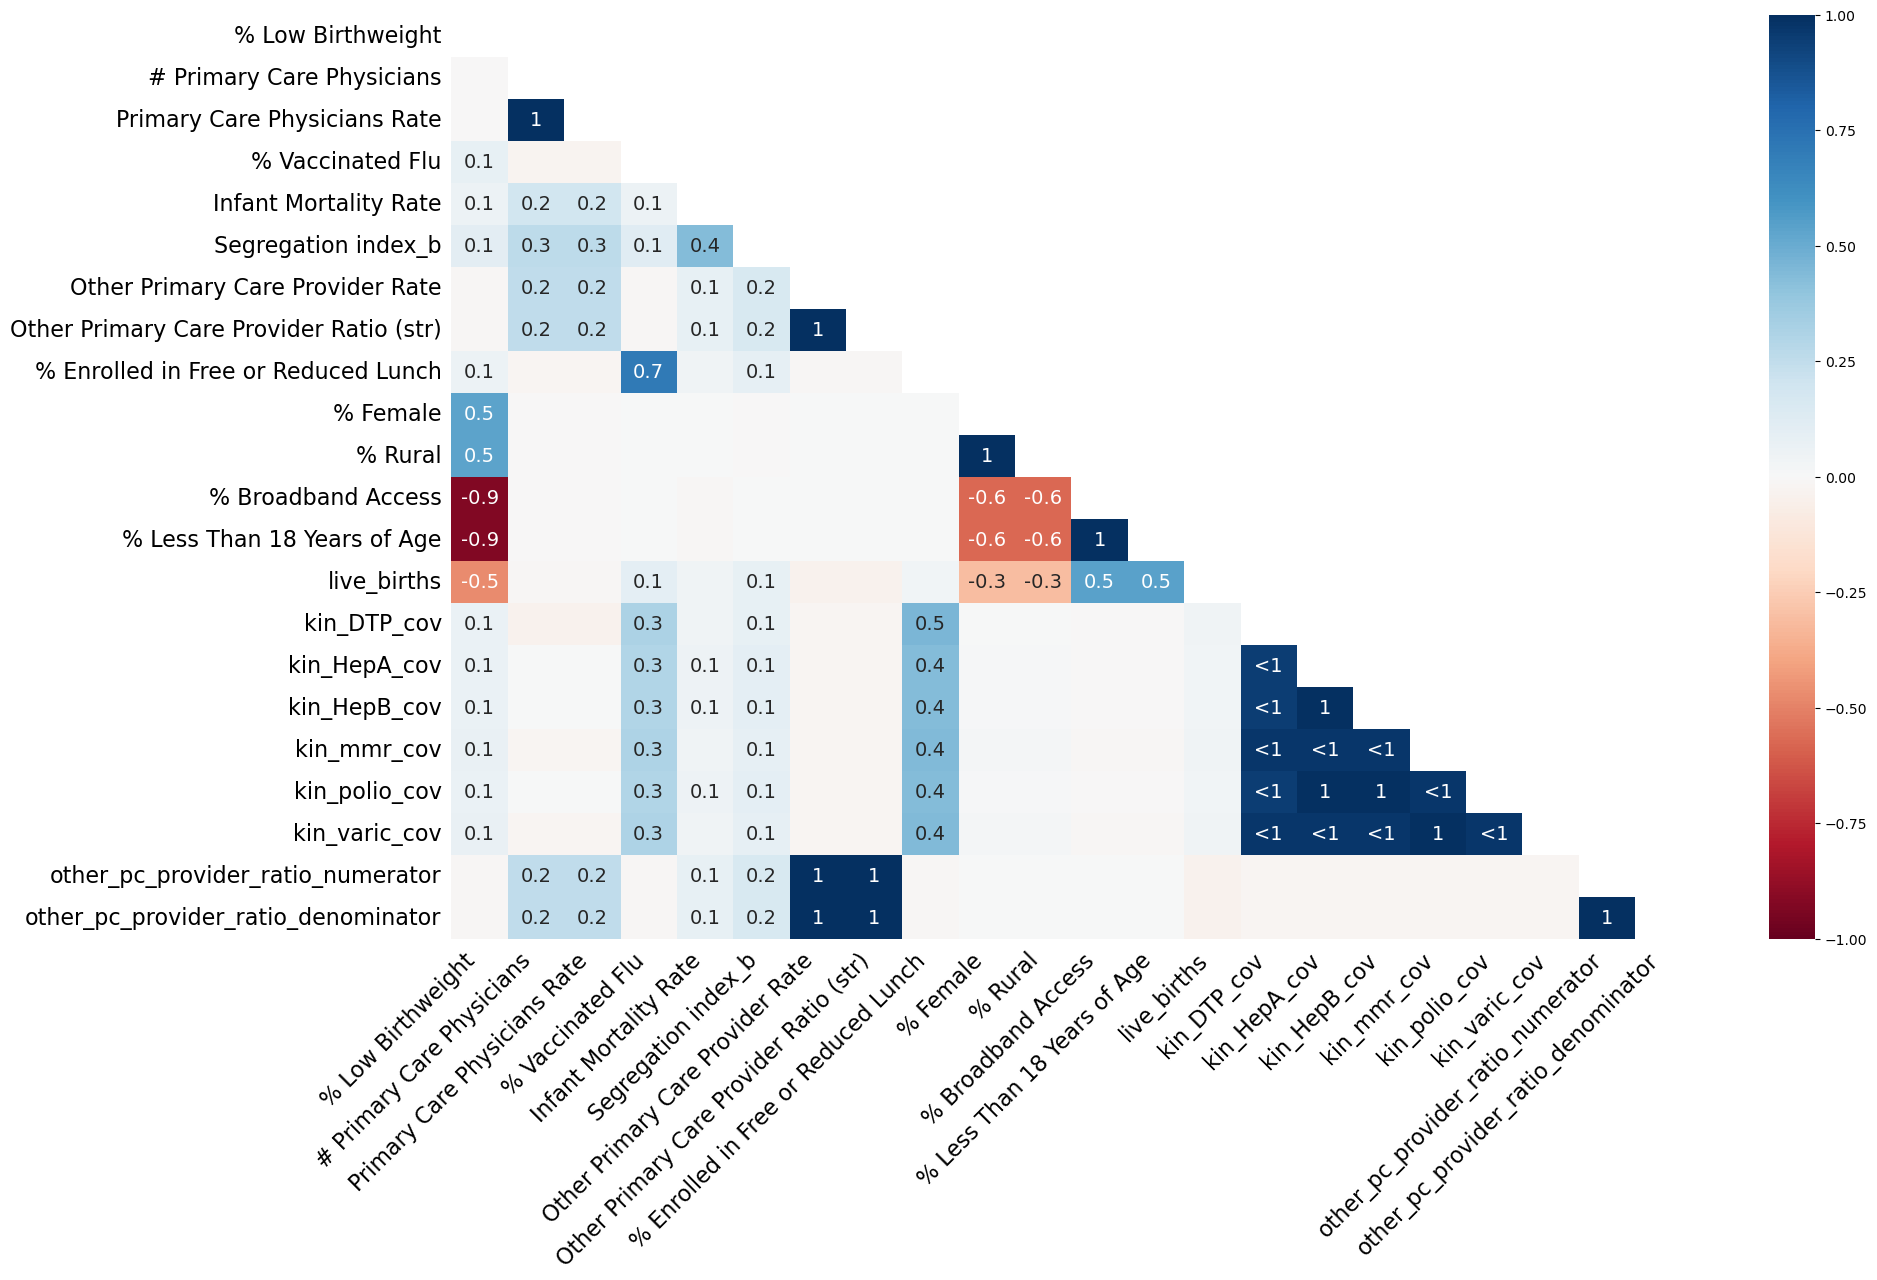

In [57]:
# visually examine patterns in missingness
msno.heatmap(data)

In [58]:
for col in ['% Low Birthweight','% Broadband Access','Segregation index_b','% Female']:
    missing_by_year = data.groupby('year')[col].apply(lambda x: x.isna().mean())
    print(f"\nMissingness in {col} by year:")
    print(missing_by_year)


Missingness in % Low Birthweight by year:
year
2020    0.074803
2021    1.000000
2022    1.000000
2023    0.074803
Name: % Low Birthweight, dtype: float64

Missingness in % Broadband Access by year:
year
2020    1.0
2021    0.0
2022    0.0
2023    1.0
Name: % Broadband Access, dtype: float64

Missingness in Segregation index_b by year:
year
2020    0.334646
2021    0.338583
2022    0.338583
2023    0.346457
Name: Segregation index_b, dtype: float64

Missingness in % Female by year:
year
2020    0.0
2021    0.0
2022    1.0
2023    0.0
Name: % Female, dtype: float64


Notes
% Low birthweight - values are missing for 2021 and 2022 but present for 2020 and 2023, could use average 
% Broadband access - values are missing for 2020 and 2023 but present for 2021 and 2023
% segregation index values don't vary by year, look at missingness by county
% female - values missing for 2022 only - could be imputed with neighboring values


In [59]:
# check to see how mean values vary across years
for col in ['% Low Birthweight','% Broadband Access','% Female']:
    mean_by_year = data.groupby('year')[col].apply(lambda x: x.mean())
    print(f"\nMean value in {col} by year:")
    print(mean_by_year)


Mean value in % Low Birthweight by year:
year
2020    8.072009
2021         NaN
2022         NaN
2023    8.081984
Name: % Low Birthweight, dtype: float64

Mean value in % Broadband Access by year:
year
2020          NaN
2021    73.095962
2022    76.948015
2023          NaN
Name: % Broadband Access, dtype: float64

Mean value in % Female by year:
year
2020    49.064012
2021    49.125907
2022          NaN
2023    48.761255
Name: % Female, dtype: float64


#### Impute 'live_births' - commented out

In [60]:
# impute values for the Low Birth weight column for each county based on the values for other years
int_list_2020_2023 = [2020,2023]
int_list_2021_2022 = [2021,2022]

#lbw_mean_2020_2023_by_county = (data.loc[data['year'].isin(int_list_2020_2023)]
#    .groupby('county_name')['% Low Birthweight']
#    .mean()
#)
#print(lbw_mean_2020_2023_by_county)

In [61]:
# for each county replace 2021 and 2022 null values with the mean of 2020 and 2023 values 
mask = (data['year'].isin([2021, 2022])) & (data['% Low Birthweight'].isnull())
#data.loc[mask, '% Low Birthweight'] = (
#    data.loc[mask, 'county_name'].map(lbw_mean_2020_2023_by_county)
#)
#print(data.loc[mask, ['county_name', 'year', '% Low Birthweight']].sort_values(by= 'county_name').head())
data.shape

(1016, 42)

Now the null value for 2021 and 2022 are replaced in with the mean.

#### Impute % Broadband Access - commented out

In [62]:
broadb_mean_by_year = (data
    .groupby('year')['% Broadband Access']
    .mean()
)
print(broadb_mean_by_year,"\n")

year
2020          NaN
2021    73.095962
2022    76.948015
2023          NaN
Name: % Broadband Access, dtype: float64 



In [63]:
print("The % change change from 2021 to 2022")
(76.948015-73.095962)/73.095962

The % change change from 2021 to 2022


0.05269857451222816

In [64]:
# impute values for the % broadband access column for each county based on the values for other years

broadb_mean_2021_2022_by_county = (data.loc[data['year'].isin(int_list_2021_2022)]
    .groupby('county_name')['% Broadband Access']
    .mean()
)
print(broadb_mean_2021_2022_by_county,"\n")

# for each county replace 2020 and 2023 null values with the mean of 2021 and 2022 values 
#data_test = data.copy()
#mask = (data['year'].isin(int_list_2020_2023)) & (data['% Broadband Access'].isnull())
#data_test.loc[mask, '% Broadband Access'] = (
#    data_test.loc[mask, 'county_name'].map(broadb_mean_2021_2022_by_county)
#)
#print(data_test.loc[mask, ['county_name', 'year', '% Broadband Access']].sort_values(by= 'county_name').head())
#data_test.shape
#data = data_test

county_name
Anderson    71.135936
Andrews     87.630549
Angelina    83.819458
Aransas     83.420779
Archer      76.586926
              ...    
Wood        78.869599
Yoakum      79.277289
Young       77.379648
Zapata      60.193254
Zavala      57.076687
Name: % Broadband Access, Length: 254, dtype: float64 



#### Impute % Female - commented out

In [65]:
female_proportion_by_year = (data
    .groupby('year')['% Female']
    .mean()
)
print(female_proportion_by_year,"\n")

year
2020    49.064012
2021    49.125907
2022          NaN
2023    48.761255
Name: % Female, dtype: float64 



In [66]:
# impute values for the % Female column for each county based on the values for other years
int_list_2020_2021_2023 = [2022,2021,2023]

#female_mean_2020_2021_2023_by_county = (data.loc[data['year']!= 2022]
#    .groupby('county_name')['% Female']
#    .mean()
#)
#print(female_mean_2020_2021_2023_by_county,"\n")

# for each county replace 2022 null values with the mean of 2021, 2022 and 2023 values 
#data_test = data.copy()
#mask = (data['year']== 2022) & (data['% Female'].isnull())
#data_test.loc[mask, '% Female'] = (
#    data_test.loc[mask, 'county_name'].map(female_mean_2020_2021_2023_by_county)
#)
#print(data_test.loc[mask, ['county_name', 'year', '% Female']].sort_values(by= 'county_name').head())
#data_test.shape
#data = data_test

#### Impute segregation_b by county - commented out

In [67]:
data['seg_missing_bool'] = data['Segregation index_b'].isnull()
print(type(data['seg_missing_bool']))
print(data.filter(like ='seg').columns)
print(data['seg_missing_bool'].head())

seg_missing_by_county = (data
    .groupby(['county_name'])['seg_missing_bool']
    .mean()
    .to_frame()
)
print(seg_missing_by_county.head())
print(type(seg_missing_by_county['seg_missing_bool']))
# column now shows the proportion of records (4 years) for each county that were missing

<class 'pandas.core.series.Series'>
Index(['seg_missing_bool'], dtype='object')
0    False
1    False
2    False
3    False
4     True
Name: seg_missing_bool, dtype: bool
             seg_missing_bool
county_name                  
Anderson                 0.00
Andrews                  0.25
Angelina                 0.00
Aransas                  0.50
Archer                   1.00
<class 'pandas.core.series.Series'>


In [68]:
seg_missing_by_county.value_counts()

seg_missing_bool
0.00                158
1.00                 76
0.50                  9
0.75                  6
0.25                  5
Name: count, dtype: int64

Most counties (158) aren't missing any values. 76 are missing all of them, and 20 are missing 1-3 values.

In [69]:
# list all the counties that are missing more than a single year of data
counties_missing_all = seg_missing_by_county.loc[seg_missing_by_county['seg_missing_bool']>0.75].sort_values(by = 'seg_missing_bool').index
print("Counties missing all segregation index_b values for all four years:\n\n", counties_missing_all)

Counties missing all segregation index_b values for all four years:

 Index(['Archer', 'Montague', 'Mills', 'Menard', 'McMullen', 'Mason', 'Martin',
       'Lynn', 'Loving', 'Live Oak', 'Lipscomb', 'La Salle', 'Kinney', 'King',
       'Kimble', 'Kent', 'Motley', 'Kenedy', 'Oldham', 'Presidio', 'Willacy',
       'Throckmorton', 'Terrell', 'Sutton', 'Stonewall', 'Sterling', 'Starr',
       'Somervell', 'Sherman', 'Shackelford', 'Schleicher', 'San Saba',
       'Roberts', 'Real', 'Reagan', 'Parmer', 'Jim Hogg', 'Jeff Davis', 'Jack',
       'Concho', 'Collingsworth', 'Coke', 'Cochran', 'Clay', 'Carson',
       'Callahan', 'Brooks', 'Briscoe', 'Brewster', 'Borden', 'Blanco',
       'Bandera', 'Bailey', 'Armstrong', 'Cottle', 'Crane', 'Crockett',
       'Culberson', 'Irion', 'Hudspeth', 'Hemphill', 'Hartley', 'Hardeman',
       'Hansford', 'Hamilton', 'Zapata', 'Hall', 'Gillespie', 'Foard',
       'Edwards', 'Duval', 'Dimmit', 'Dickens', 'Dallam', 'Glasscock',
       'Zavala'],
      dtype='

I don't see any clear pattern that explains why the segregation index_b is missing. I could impute it but the choice of a fillvalue would be pretty arbitrary. Could use the mean for a given year across all counties.

In [70]:
# impute values for the missing column
#x = imputer.fit_transform(data[['Segregation index_b']])
#imputed_segregation_df = pd.DataFrame(x, columns = ['segregation_imputed', 'segregation_imputed_yes_no'])

In [71]:
# add imputed variables back to the original data frame
#print(f"Original data frame shape: {data.shape}")
#print(f"Imputed %segregation index data frame shape: {imputed_segregation_df.shape}")
#data_test = pd.concat([data,imputed_segregation_df], axis = 1)
#print(f"Combined data frame shape: {data_test.shape}")

In [72]:
#data = data_test

## MMR coverage

In [73]:
low_outlier_threshold = data['kin_mmr_cov'].quantile(0.01)
low_outlier_threshold

0.8097721012421392

In [74]:
low_outlier_threshold_mask = data['kin_mmr_cov'] < low_outlier_threshold
low_outliers_df = data.loc[low_outlier_threshold_mask][['county_name','kin_mmr_cov','year']].sort_values(by = ['kin_mmr_cov'], ascending = True)
print(low_outliers_df.shape)
print(low_outliers_df)

(10, 3)
      county_name  kin_mmr_cov  year
896          King     0.500000  2023
477  Throckmorton     0.631579  2021
948          Polk     0.650284  2023
654     Limestone     0.730104  2022
642          King     0.733333  2022
349          Hall     0.789474  2021
385          Kent     0.800000  2021
839         Foard     0.800000  2023
82         Gaines     0.804348  2020
336        Gaines     0.808118  2021


In [75]:
low_outliers_df.sort_values(by = ['county_name', 'kin_mmr_cov'], ascending = False)

,county_name,kin_mmr_cov,year
477,Throckmorton,0.631579,2021
948,Polk,0.650284,2023
654,Limestone,0.730104,2022
642,King,0.733333,2022
896,King,0.500000,2023
385,Kent,0.800000,2021
349,Hall,0.789474,2021
336,Gaines,0.808118,2021
82,Gaines,0.804348,2020
839,Foard,0.800000,2023


In [76]:
low_outliers_df.groupby(['county_name'])['kin_mmr_cov'].median().sort_values(ascending = True)

county_name
King            0.616667
Throckmorton    0.631579
Polk            0.650284
Limestone       0.730104
Hall            0.789474
Foard           0.800000
Kent            0.800000
Gaines          0.806233
Name: kin_mmr_cov, dtype: float64

I'm guessing many of these counties just had unusual reporting circumstances or poor data that year which led to the outliers.
Especially Throckmorton and Polk for those particular years. Check to see what values those counties had for other years where their MMR coverage was not a low outlier.

In [77]:
low_counties_list = low_outliers_df.iloc[:,0].to_list()
data.loc[data['county_name'].isin(low_counties_list),['county_name','year','kin_mmr_cov']].sort_values(by = ['county_name','year'], ascending = False)
#data.loc[data['county_name'].isin(low_counties_list), ['county_name', 'year', 'kin_mmr_cov']]


,county_name,year,kin_mmr_cov
985,Throckmorton,2023,0.857143
731,Throckmorton,2022,0.954545
477,Throckmorton,2021,0.631579
223,Throckmorton,2020,1.000000
948,Polk,2023,0.650284
694,Polk,2022,0.969424
440,Polk,2021,0.963710
186,Polk,2020,0.946108
908,Limestone,2023,0.809859
654,Limestone,2022,0.730104


For at least Throckmorton and King counties, the outlying value is so much lower than the preceding year or the preceding and following year, they probably reflect data quality issues and not real variations in coverage. Based on this, keep most of these values and impute only those in the lowest 0.5% of data set 

In [78]:
lower_outlier_threshold = data['kin_mmr_cov'].quantile(0.005)
lower_outlier_threshold
lower_outlier_threshold_mask = data['kin_mmr_cov']< data['kin_mmr_cov'].quantile(0.005)

In [79]:
# compare the distributions with and without the coverage outliers removed

trimmed_data = data.copy()
trimmed_data.loc[trimmed_data['kin_mmr_cov'] < lower_outlier_threshold, 'kin_mmr_cov'] = pd.NA

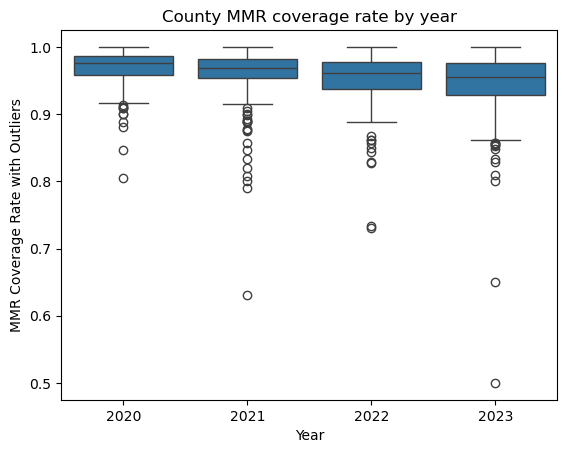

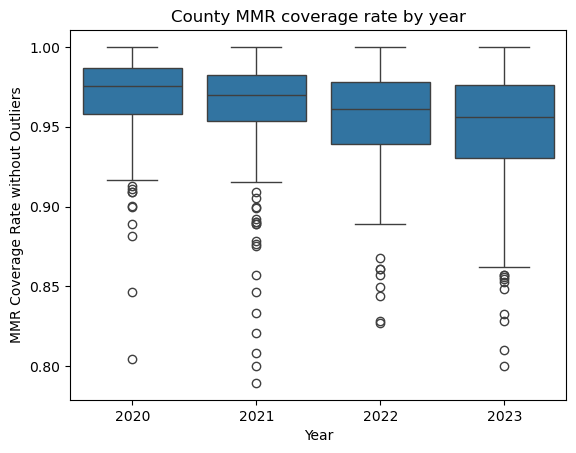

In [80]:

# Make box plot of by year
_ = sns.boxplot(x = 'year', y = 'kin_mmr_cov', data = data)
# Label the axes
_ = plt.xlabel('Year')
_ = plt.ylabel('MMR Coverage Rate with Outliers')
_ = plt.title('County MMR coverage rate by year')
# Show the plot
plt.show()

# Make box plot of by year
_ = sns.boxplot(x = 'year', y = 'kin_mmr_cov', data = trimmed_data)
# Label the axes
_ = plt.xlabel('Year')
_ = plt.ylabel('MMR Coverage Rate without Outliers')
_ = plt.title('County MMR coverage rate by year')
# Show the plot
plt.show()

### Correlations

In [81]:
# originally, there were 37 numerical columns
numerical_cols2 = data.select_dtypes(['int','float']).columns
print(len(numerical_cols2))
numerical_cols2

37


Index(['% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'mmr_doses_0_24_months', 'mmr_doses_2_8_years', 'mmr_doses_9_17_years',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout',
       'other_pc_provider_ratio_numerator',
       'other_pc_provider_ratio_denominator'

In [82]:
primary_features = (['kin_mmr_cov',
                     'Primary Care Physicians Rate',
                     'other_pc_provider_ratio_numerator',
                     'Infant Mortality Rate',
                     '% Uninsured Children',
                     'Other Primary Care Provider Rate',
                     'Population', 
                     '% Female',
                     'Estimated strongly hesitant',
                     'CVAC level of concern for vaccination rollout']
                     )

In [83]:
secondary_features = (['kin_mmr_cov',
                       '% Low Birthweight',
                       '% Children in Poverty',
                       '% Food Insecure','Segregation index_b',
                       'Median Household Income',
                       '% Enrolled in Free or Reduced Lunch',
                       '% Rural',
                       '% Broadband Access',
                       'Social Vulnerability Index (SVI)']
                       )

In [84]:
data[secondary_features].dtypes

kin_mmr_cov                            float64
% Low Birthweight                      float64
% Children in Poverty                  float64
% Food Insecure                        float64
Segregation index_b                    float64
Median Household Income                  int64
% Enrolled in Free or Reduced Lunch    float64
% Rural                                float64
% Broadband Access                     float64
Social Vulnerability Index (SVI)       float64
dtype: object

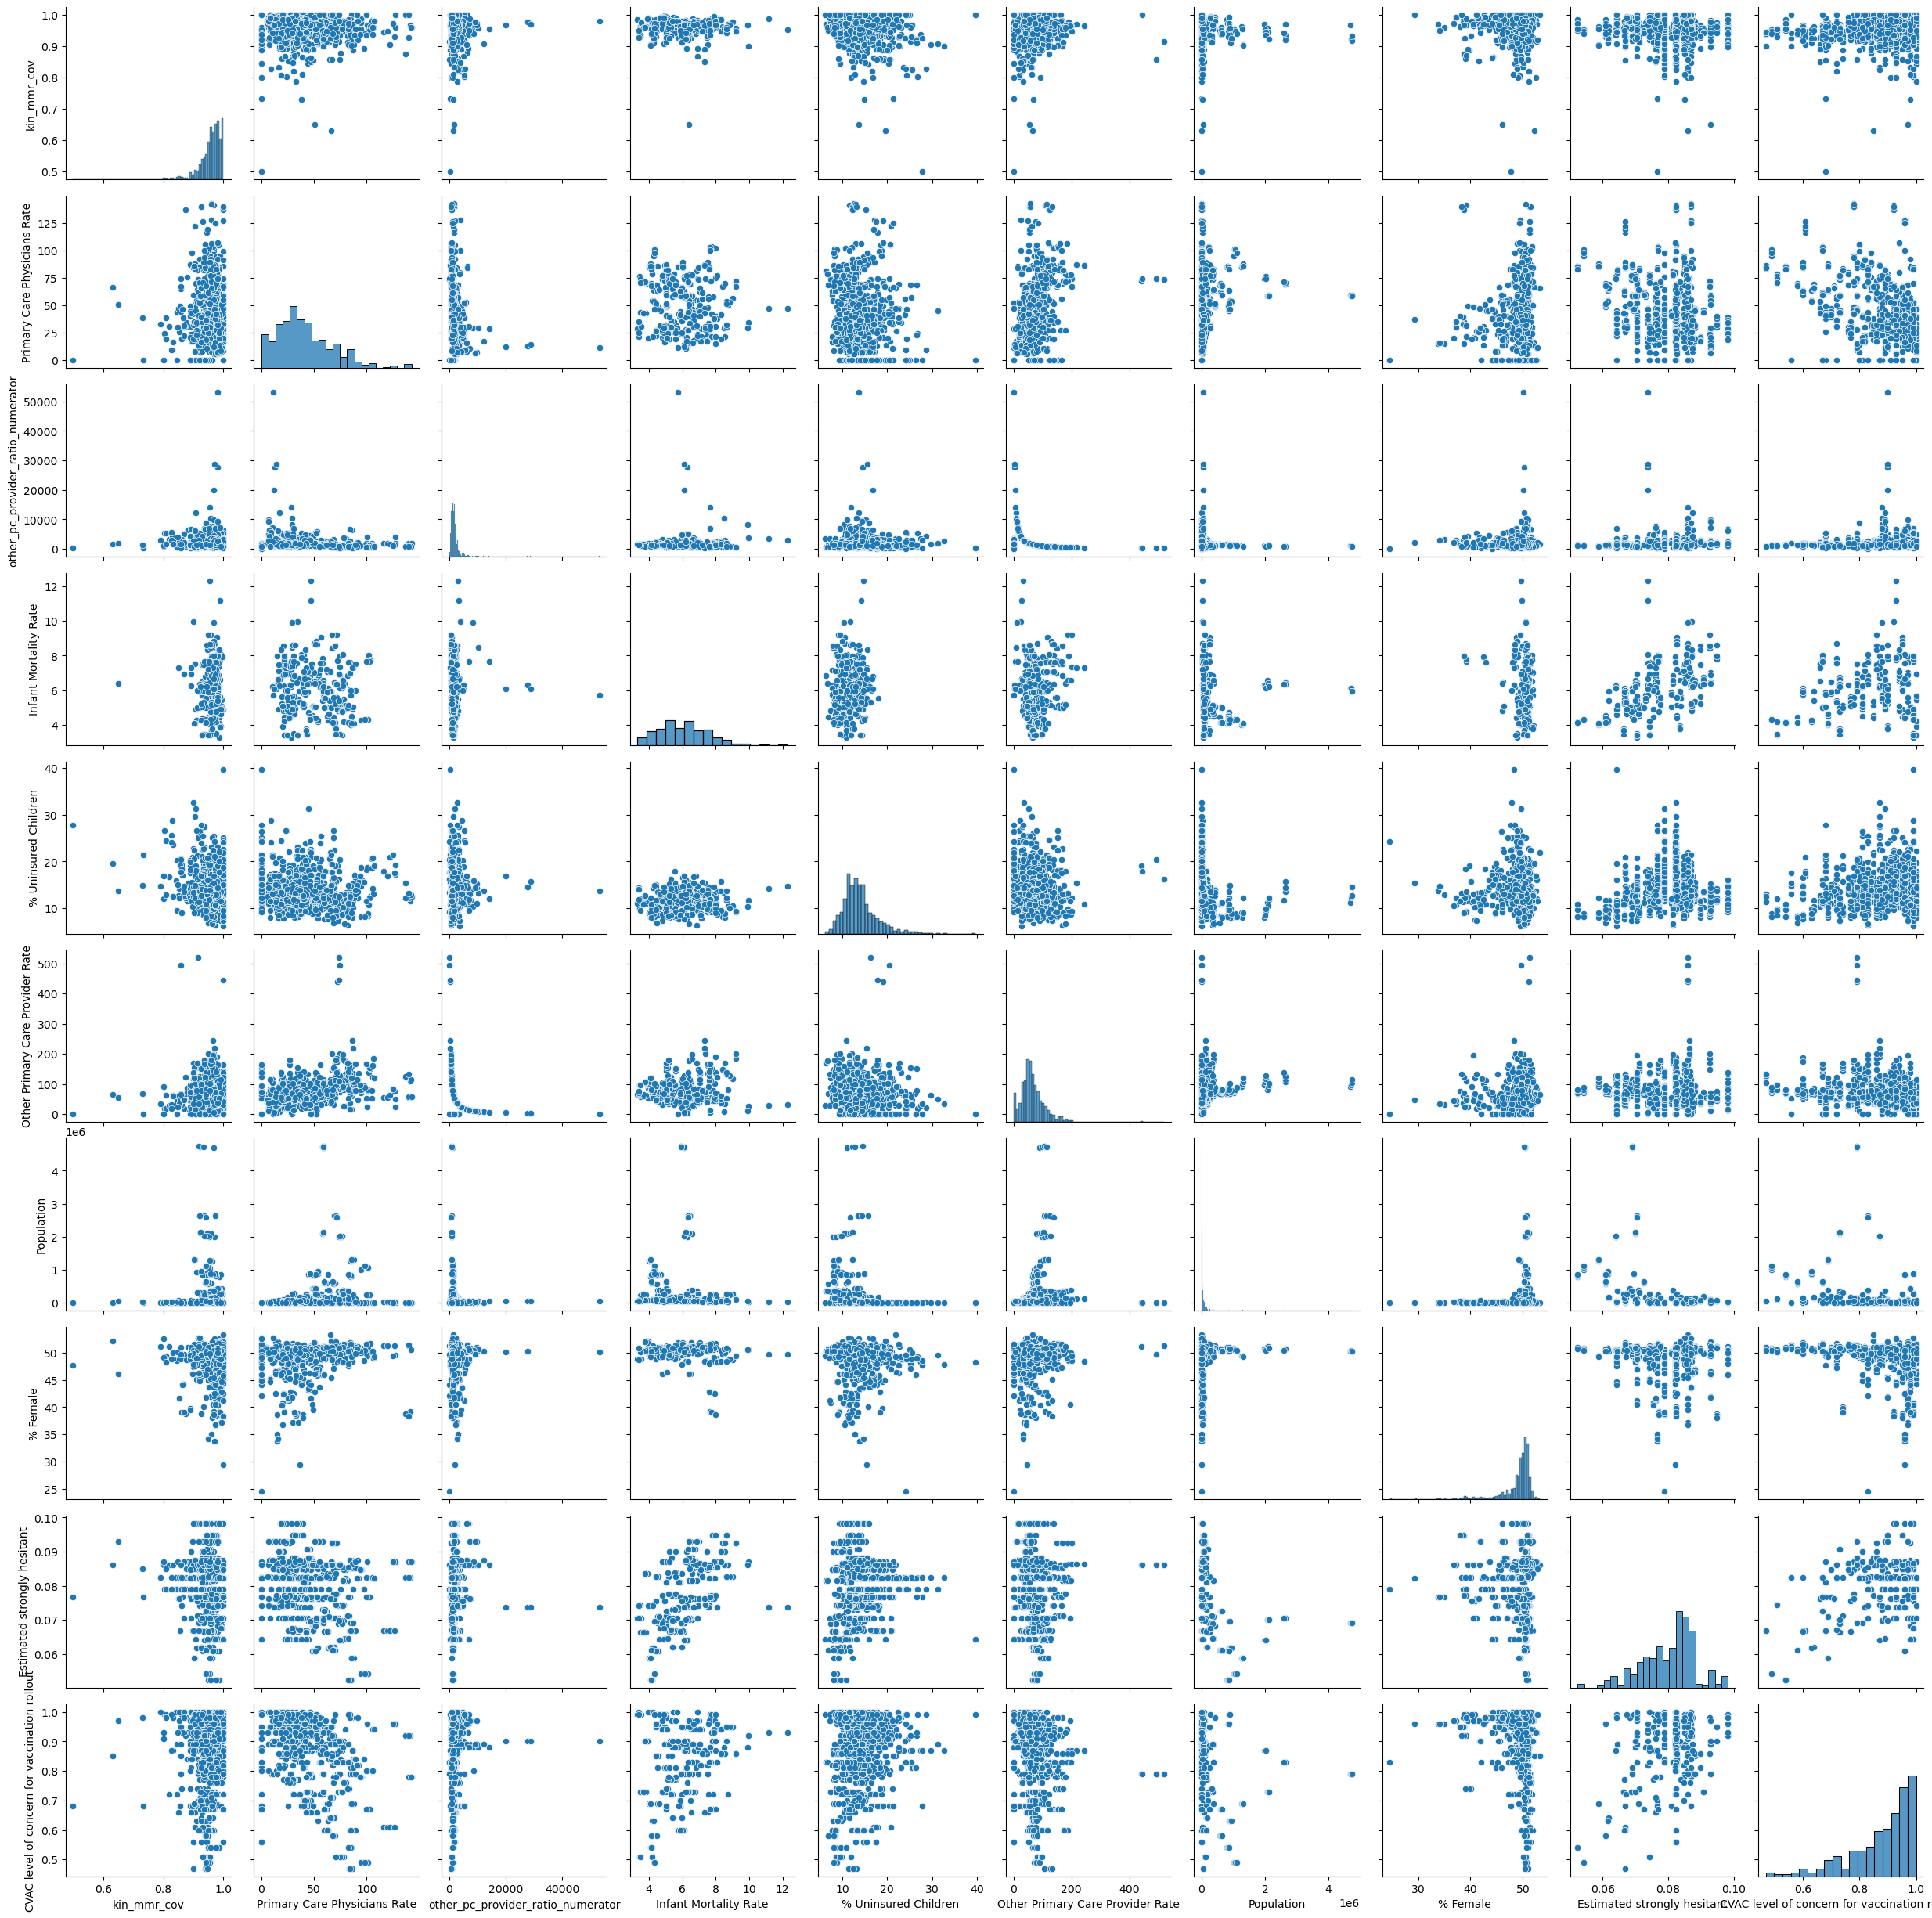

In [85]:
g = sns.PairGrid(data[primary_features], corner=False, diag_sharey=True, height=2.5, aspect=1, layout_pad=0.5, despine=True, dropna=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

Observations:
- The relationship between MMR dose rate 0-24 months is not at all linearly related with the MMR coverage rates among kindergarteners
- There is surprisingly very non-linear relationship betwen the 'Other Primary Care Provider Rate' and the 'other_pc_provider_ratio_numerator' which is a reminder to look more closely at what those variables mean in the documentation.
- IMR appears to be correlated with COVID-19 hesitancy levels as well as the CVAC level of concern for COVID-19 roll out. This make sense if the level of concern was based in part on IMR. Maybe more interesting is the association between IMR and COVID-19 vaccine hesitancy.
- % Uninsured Children is correlated with COVID-19 hesitancy levels as well as the CVAC level of concern for COVID-19 roll out. The association between level of concern and % uninsured makes sense makes sense if the level of concern was based in part on the % of uninsured. What's more interesting is the association between % uninsured and the COVID-19 vaccine hesitancy.
- 

In [86]:
primary_features_only = data[primary_features]
(primary_features_only
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,kin_mmr_cov,Primary Care Physicians Rate,other_pc_provider_ratio_numerator,Infant Mortality Rate,% Uninsured Children,Other Primary Care Provider Rate,Population,% Female,Estimated strongly hesitant,CVAC level of concern for vaccination rollout
kin_mmr_cov,1.000000,-0.005216,0.009913,0.020830,-0.218491,0.008272,-0.048838,0.007396,-0.057482,0.164000
Primary Care Physicians Rate,-0.005216,1.000000,-0.159559,-0.131110,-0.122758,0.399511,0.221842,0.135689,-0.240524,-0.339388
other_pc_provider_ratio_numerator,0.009913,-0.159559,1.000000,0.057689,0.018858,-0.365252,-0.084960,0.005178,0.073244,0.112904
Infant Mortality Rate,0.020830,-0.131110,0.057689,1.000000,0.139368,0.062439,-0.140222,-0.164773,0.573468,0.254243
% Uninsured Children,-0.218491,-0.122758,0.018858,0.139368,1.000000,-0.055515,-0.182705,-0.063546,0.155823,0.138941
Other Primary Care Provider Rate,0.008272,0.399511,-0.365252,0.062439,-0.055515,1.000000,0.155505,0.111841,-0.070043,-0.165980
Population,-0.048838,0.221842,-0.084960,-0.140222,-0.182705,0.155505,1.000000,0.115518,-0.346007,-0.226623
% Female,0.007396,0.135689,0.005178,-0.164773,-0.063546,0.111841,0.115518,1.000000,-0.051322,-0.247228
Estimated strongly hesitant,-0.057482,-0.240524,0.073244,0.573468,0.155823,-0.070043,-0.346007,-0.051322,1.000000,0.259733
CVAC level of concern for vaccination rollout,0.164000,-0.339388,0.112904,0.254243,0.138941,-0.165980,-0.226623,-0.247228,0.259733,1.000000


Observations

- No correlation between mmr dose rate 0-24 months and the MMR coverage rate
- Note the weak negative correlation betwen the 'Other Primary Care Provider Rate' and the 'other_pc_provider_ratio_numerator'
- Moderate association between **population size** and the % of pop that was strongly hesitant to take the COVID-19 vaccine in 2021, counties with smaller populations have greater % of COVID-19 vaccine hesitancy
- Weak positive correlation between **CVAC level** and MMR coverage rate, makes sense
- Weak negative correlation between **% of uninsured children** in a county and the MMR coverage rate among kindergarteners
- Moderate positive correlation between IMR and % strongly hesistant of COVID-19 vaccine
- Moderate positive correlation between county population and mmr_dose_rate, interesting


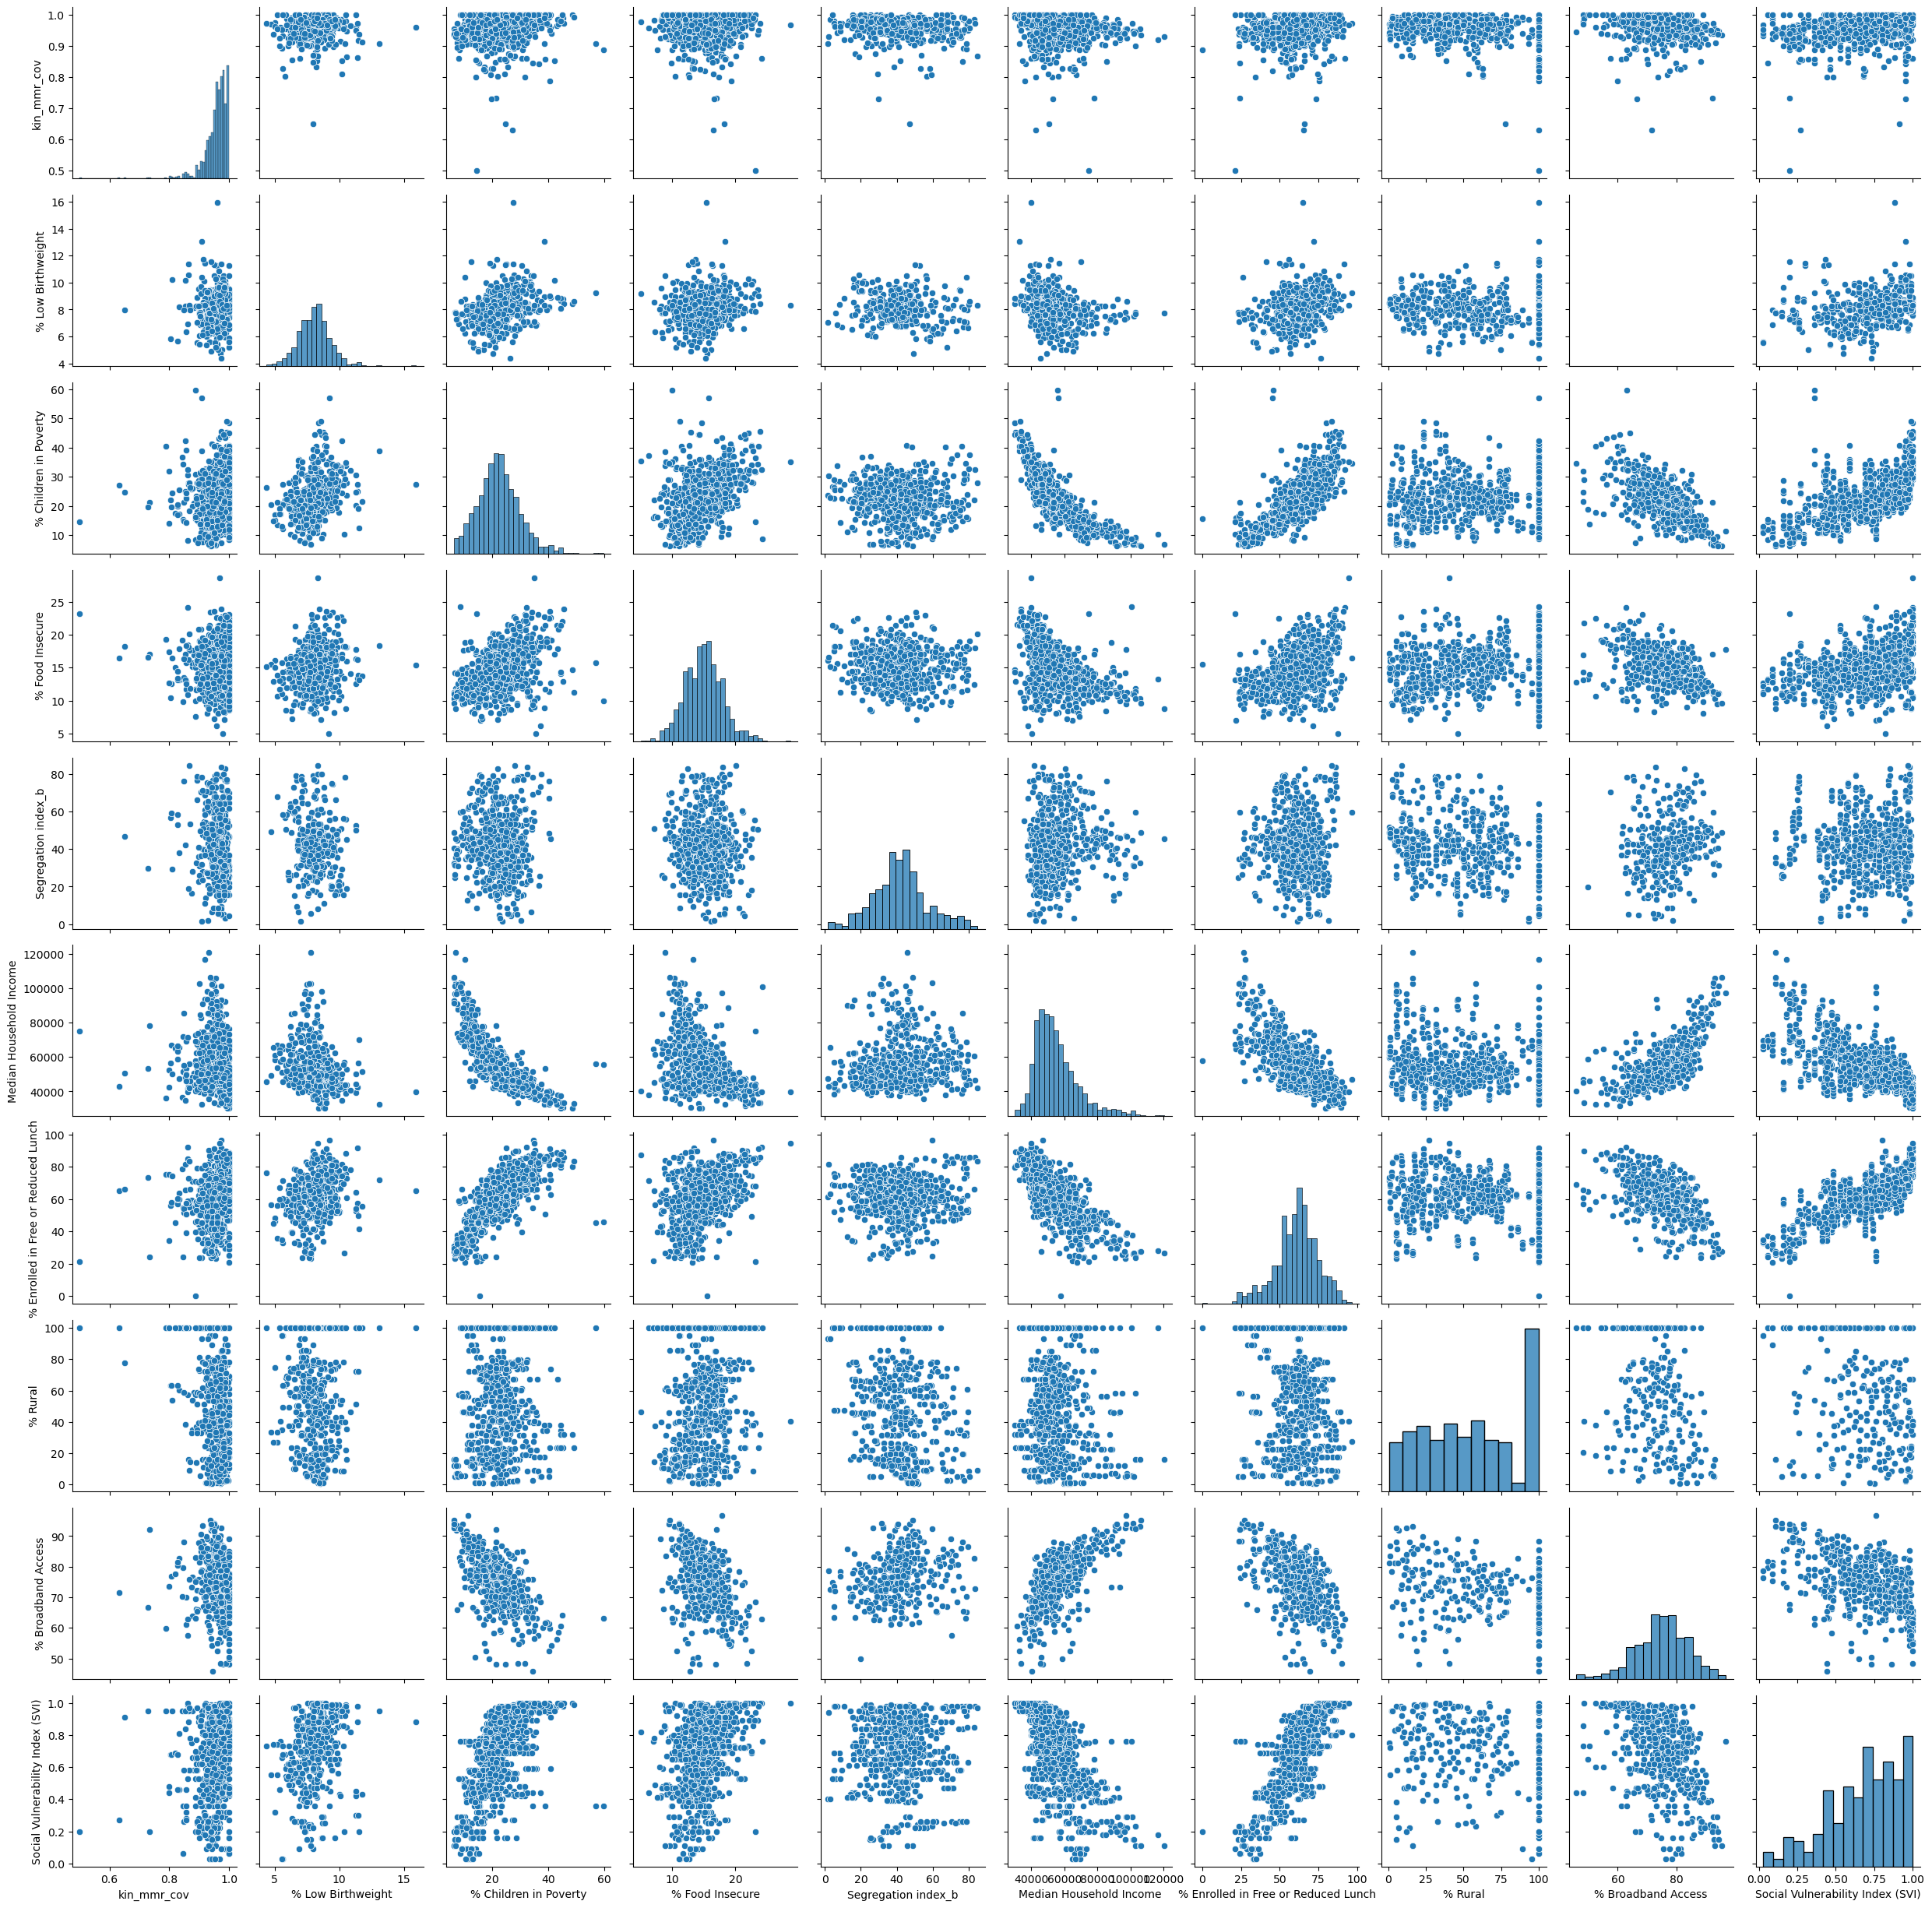

In [87]:
g = sns.PairGrid(data[secondary_features], corner=False, diag_sharey=True, height=2.5, aspect=1, layout_pad=0.5, despine=True, dropna=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

Observations:
- Notice the homogenous data introduced by the imputed values for % pop_youth_imputed which appears as straight line of dots
- May socieconomic indicators are related in the way one would expect. For example median household income and broadband access are positively correlated at the county level. Poorer counties have less broadban access. Similarily, % children in poverty is positively correlated with the % enrolled in free or reduced lunch
- No clear correlations between the mmr_dose rate and other variables

In [88]:
secondary_features_only = data[secondary_features]
(secondary_features_only
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,kin_mmr_cov,% Low Birthweight,% Children in Poverty,% Food Insecure,Segregation index_b,Median Household Income,% Enrolled in Free or Reduced Lunch,% Rural,% Broadband Access,Social Vulnerability Index (SVI)
kin_mmr_cov,1.000000,0.040623,0.122234,-0.040420,-0.129358,-0.166081,0.175844,-0.130679,-0.139060,0.189726
% Low Birthweight,0.040623,1.000000,0.318127,0.177965,-0.128984,-0.267503,0.259626,-0.074402,nan,0.275205
% Children in Poverty,0.122234,0.318127,1.000000,0.436234,-0.008932,-0.804950,0.748795,0.077440,-0.621115,0.624278
% Food Insecure,-0.040420,0.177965,0.436234,1.000000,-0.051721,-0.442710,0.388603,0.125086,-0.391814,0.401005
Segregation index_b,-0.129358,-0.128984,-0.008932,-0.051721,1.000000,0.078197,0.037864,-0.242346,0.168630,0.002540
Median Household Income,-0.166081,-0.267503,-0.804950,-0.442710,0.078197,1.000000,-0.724284,-0.164828,0.663085,-0.636349
% Enrolled in Free or Reduced Lunch,0.175844,0.259626,0.748795,0.388603,0.037864,-0.724284,1.000000,-0.117061,-0.548213,0.775227
% Rural,-0.130679,-0.074402,0.077440,0.125086,-0.242346,-0.164828,-0.117061,1.000000,-0.237636,-0.245413
% Broadband Access,-0.139060,nan,-0.621115,-0.391814,0.168630,0.663085,-0.548213,-0.237636,1.000000,-0.445017
Social Vulnerability Index (SVI),0.189726,0.275205,0.624278,0.401005,0.002540,-0.636349,0.775227,-0.245413,-0.445017,1.000000


Observations:
- Weak associationgs between MMR coverage rate among kindergarteners and **% of children in poverty (positive association)**, **median household income (negative)**, **% enrolled in free or reduced lunch (positive)**, and **SVI (positive)**. 
- Strong correlations among SVI, % enrolled in free or reduced lunch, % food insecure, % broadband access, and median household income probably indicate I'll run into collinearity problems if I try to throw all of those in a single model
- Like the pair plot, there are no strong associations between mmr_dose_rate and any of the features


#### Plots for MMR Coverage

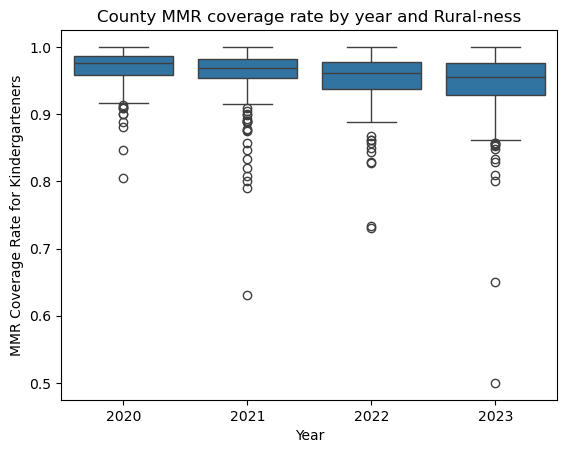

In [89]:
# Make box plot of by year
_ = sns.boxplot(x = 'year', y = 'kin_mmr_cov', data = data)

# Label the axes
_ = plt.xlabel('Year')
_ = plt.ylabel('MMR Coverage Rate for Kindergarteners')
_ = plt.title('County MMR coverage rate by year and Rural-ness')
# Show the plot
plt.show()

At the same time that MMR dose counts sky rocketed in 2023, MMR coverage rates seem to trend downward as shown in the box plot above. In both the MMR count and MMR coverage box plots, variation seems to increase year over year.

In [90]:
# make a box plot showing distribution of a mmr dose rates in 2023
mask2023 = data['year'] == 2023
print(type(mask2023))
data2023 = data.loc[mask2023,:]

<class 'pandas.core.series.Series'>


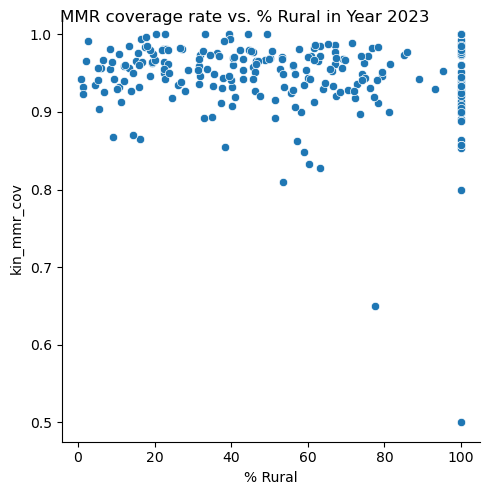

In [91]:
# make a box plot showing distribution of a mmr coverage rates in 2023
g = sns.relplot(data= data2023, x = "% Rural", y = "kin_mmr_cov")
g.fig.suptitle("MMR coverage rate vs. % Rural in Year 2023")
plt.show()

In [92]:
# For 2023, view the counties with the top 10 kindergarten MMR coverage rates and their populations alongside their mmr dose count rate per child
mask2023 = (data['year'] ==2023)
data.loc[mask2023, ['county_name', 'kin_mmr_cov']].sort_values('kin_mmr_cov', ascending = True).head(10)

,county_name,kin_mmr_cov
896,King,0.500000
948,Polk,0.650284
839,Foard,0.800000
908,Limestone,0.809859
844,Gaines,0.828125
828,Eastland,0.832558
930,Montague,0.848624
857,Hall,0.852941
889,Karnes,0.854396
777,Blanco,0.855932


The counties with the lowest MMR coverage rates at kindergarten also have fairly low MMR dose rates. 
King and Polk seem like definite outliers, they're the only two counties with <80% MMR coverage among kindergarteners and they are both rural.

In [93]:
# For 2022, view the counties with the top 10 kindergarten MMR coverage rates and their populations alongside their mmr dose count rate per child
mask2022 = (data['year'] ==2022)
data.loc[mask2022, ['county_name', 'kin_mmr_cov']].sort_values('kin_mmr_cov', ascending = True).head(10)

,county_name,kin_mmr_cov
654,Limestone,0.730104
642,King,0.733333
718,Sherman,0.826923
590,Gaines,0.828571
603,Hall,0.843750
618,Hood,0.849862
530,Briscoe,0.857143
631,Jim Hogg,0.860759
696,Presidio,0.861111
676,Montague,0.867521


## Clean and examine categorical variables

In [94]:
categorical_cols = data.select_dtypes(['object']).columns
print(len(categorical_cols))
categorical_cols

5


Index(['county_name', 'Other Primary Care Provider Ratio (str)',
       'SVI Category', 'CVAC Level Of Concern', 'pop_tertiles'],
      dtype='object')

In [95]:
data['SVI Category'].unique()

array(['High Vulnerability', 'Moderate Vulnerability',
       'Very High Vulnerability', 'Very Low Vulnerability',
       'Low Vulnerability'], dtype=object)

In [96]:
data['CVAC Level Of Concern'].unique()

array(['Very High Concern', 'Moderate Concern', 'High Concern'],
      dtype=object)

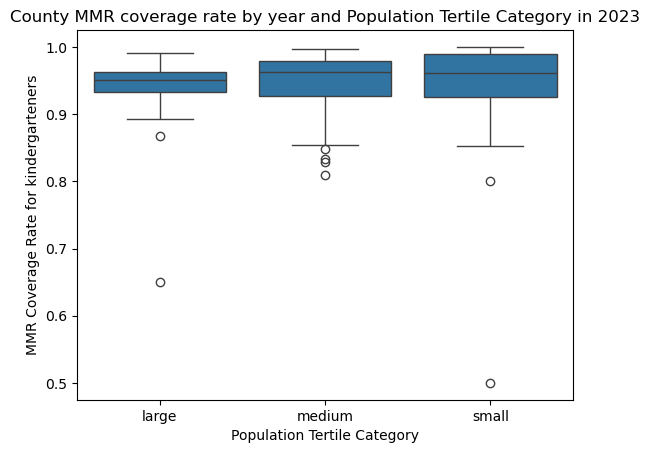

In [97]:
# Make box plot of mmr dose rate by year and category 
_ = sns.boxplot(x = 'pop_tertiles', y = 'kin_mmr_cov', data = data2023)

# Label the axes
_ = plt.xlabel('Population Tertile Category')
_ = plt.ylabel('MMR Coverage Rate for kindergarteners')
_ = plt.title('County MMR coverage rate by year and Population Tertile Category in 2023')
# Show the plot
plt.show()

Interesting that there is the highest variation in MMR dose rate in the counties with the highest proportion of vulnerable individuals. The dose rate in some of these counties is presumably even larger than the dose rate. incounties with a smaller proportion of vulnerable residents.

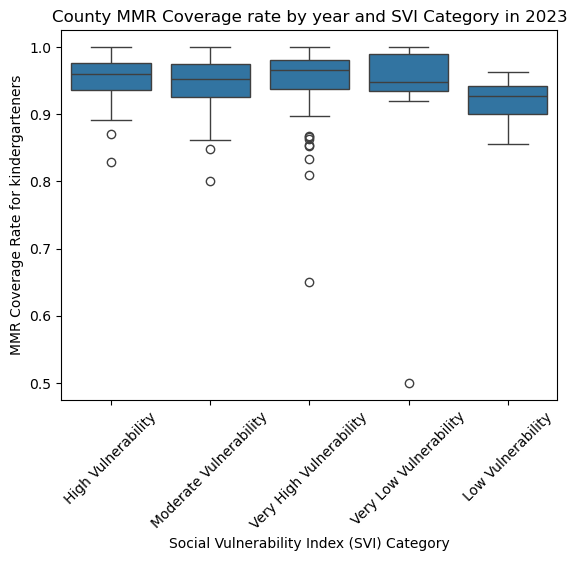

In [98]:
# Make box plot of mmr coverage rate by year and category 
_ = sns.boxplot(x = 'SVI Category', y = 'kin_mmr_cov', data = data2023)
# Rotate x-axis tick labels
_ = plt.tick_params(axis='x', rotation=45)
# Label the axes
_ = plt.xlabel('Social Vulnerability Index (SVI) Category')
_ = plt.ylabel('MMR Coverage Rate for kindergarteners')
_ = plt.title('County MMR Coverage rate by year and SVI Category in 2023')
# Show the plot
plt.show()

# Save modified data

In [99]:
# review columns and missing data
data.isnull().sum().sort_values(ascending = False)

Infant Mortality Rate                            712
% Low Birthweight                                546
% Less Than 18 Years of Age                      508
% Broadband Access                               508
Segregation index_b                              345
live_births                                      278
% Rural                                          254
% Female                                         254
# Primary Care Physicians                         82
Primary Care Physicians Rate                      82
kin_polio_cov                                     21
kin_HepB_cov                                      21
kin_HepA_cov                                      21
kin_varic_cov                                     20
kin_mmr_cov                                       20
kin_DTP_cov                                       19
Other Primary Care Provider Ratio (str)           16
Other Primary Care Provider Rate                  16
other_pc_provider_ratio_numerator             

Drop mmr dose counts since I won't be using them in this branch of analysis. Also drop the string version of the PCP ratio since i've converted that to numeric.

In [100]:
print(data.shape)
data_test = data.drop(columns= ['mmr_doses_9_17_years','mmr_doses_2_8_years','mmr_doses_0_24_months','Other Primary Care Provider Ratio (str)'])
data_test.shape

(1016, 43)


(1016, 39)

In [101]:
data = data_test

In [102]:
cd '/Users/grace/Documents/GitHubRepos/capstone2_immunization/'

/Users/grace/Documents/GitHubRepos/capstone2_immunization


In [103]:
# save the data to a new csv file
data.to_csv('processed_data/imm_df_cleaner_no_imput.csv', index=False) # don't save index as separate column